### Subagents
A deep agent can create subagents to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine (keeping the main agent’s context clean) and for providing specialized instructions.
This page covers synchronous subagents, where the supervisor blocks until the subagent finishes. For long-running tasks, parallel workstreams, or cases where you need mid-flight steering and cancellation, see Async subagents.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

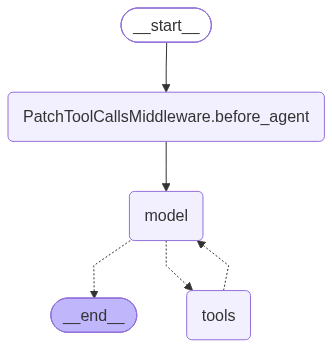

In [2]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,

):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )


research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "model": "groq:openai/gpt-oss-120b",  # Optional override, defaults to main agent model

}
subagents=[research_subagent]

agent=create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    subagents=subagents
)
agent


In [3]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "Reserach about LLM Gateways and provide me a detailed summary.",       
          }],
          
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Reserach about LLM Gateways and provide me a detailed summary.
================================== Ai Message ==================================
Tool Calls:
  grep (fc_1bd6fee6-807d-44e7-91f2-07ed8aa45ad6)
 Call ID: fc_1bd6fee6-807d-44e7-91f2-07ed8aa45ad6
  Args:
    output_mode: content
    path: /
    pattern: LLM Gateway
================================= Tool Message =================================
Name: grep

No matches found
================================== Ai Message ==================================
Tool Calls:
  grep (fc_3b21c73e-010a-486b-8e80-7c1fadaa9d99)
 Call ID: fc_3b21c73e-010a-486b-8e80-7c1fadaa9d99
  Args:
    output_mode: files_with_matches
    path: /
    pattern: gateway
================================= Tool Message =================================
Name: grep

No matches found
================================== Ai Message ==================================

**LLM Gateways – a Det

### structured Output With Sub Agents

In [4]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task."""
    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of source URLs")

research_subagent = {
    "name": "researcher",
    "description": "Researches topics and returns structured findings",
    "system_prompt": "Research the given topic thoroughly. Return your findings.",
    # Note: Groq does not allow response_format (structured/json output) to be
    # combined with tools (function calling) in the same call, so tools is
    # removed here. Use the plain agent (Cell 2/3) if you need internet_search.
    "response_format": ResearchFindings,
}

agent = create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    subagents=[research_subagent],
)

result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Research recent advances in quantum computing"}]}
)

In [5]:
# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research recent advances in quantum computing
================================== Ai Message ==================================

Below is a concise, up‑to‑date overview of the most noteworthy advances in quantum computing that have emerged over the last ≈ 3 years (2021‑2024).  The material is organized by **hardware**, **software & algorithms**, **error mitigation & correction**, and **applications & ecosystem**.  Where possible I note the key papers, press releases, or conference talks that introduced each development, so you can follow up for deeper detail.

---

## 1. Hardware – Scaling Qubit Numbers & Improving Fidelity  

| Year | Platform | Milestone | Why it matters |
|------|----------|-----------|----------------|
| **2021** | **Superconducting (IBM, Google, Rigetti)** | IBM unveiled the **Eagle** processor (127 qubits) and announced the **condor‑roadmap** targeting >1,000 qubits by 2025. | Demons